Лабораторная работа №3
=
    
**Проведение исследований с решающим деревом**

Классификация
=

**Импорт необходимых библиотек**

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, precision_recall_curve
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

**Чтение данных**

In [74]:
df = pd.read_csv('data_class.csv')

columns = ['footfall', 'tempMode', 'AQ', 'USS', 'CS', 'VOC', 'RP', 'IP', 'Temperature', 'fail']
df.columns = columns

print("Первые 5 строк:")
print(df.head())

Первые 5 строк:
   footfall  tempMode  AQ  USS  CS  VOC  RP  IP  Temperature  fail
0         0         7   7    1   6    6  36   3            1     1
1       190         1   3    3   5    1  20   4            1     0
2        31         7   2    2   6    1  24   6            1     0
3        83         4   3    4   5    1  28   6            1     0
4       640         7   5    6   4    0  68   6            1     0


**Визуализация распределения**


Распределение целевой переменной 'fail':
fail
0    551
1    393
Name: count, dtype: int64


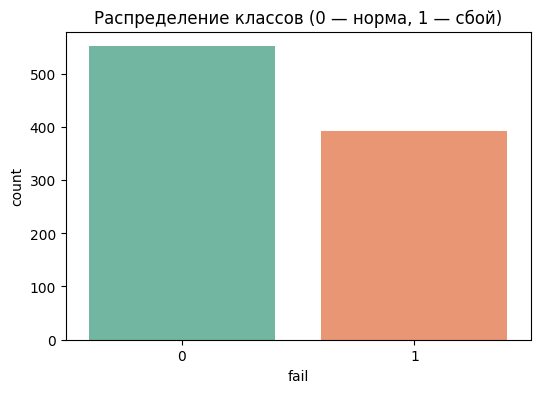

In [75]:
print("\nРаспределение целевой переменной 'fail':")
print(df['fail'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='fail', palette='Set2')
plt.title('Распределение классов (0 — норма, 1 — сбой)')
plt.show()

**Создание бейзлайна**

In [76]:
X = df.drop('fail', axis=1)
y = df['fail']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

tree_bl = DecisionTreeClassifier(random_state=42)
tree_bl.fit(X_train, y_train)
y_pred_bl = tree_bl.predict(X_test)

acc_bl = accuracy_score(y_test, y_pred_bl)
f1_bl = f1_score(y_test, y_pred_bl)

print(f"Accuracy: {acc_bl:.4f} | F1: {f1_bl:.4f}")
print(f"Глубина: {tree_bl.get_depth()} | Листьев: {tree_bl.get_n_leaves()}")

Accuracy: 0.8677 | F1: 0.8408
Глубина: 13 | Листьев: 79


**Улучшение бейзлайна**

In [77]:
param_grid = {
    'max_depth': [1, 2, 3, 4, 5, 8, 10, 12, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'class_weight': [None, 'balanced']
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid.fit(X_train, y_train)

y_pred_imp = grid.predict(X_test)
acc_imp = accuracy_score(y_test, y_pred_imp)
f1_imp = f1_score(y_test, y_pred_imp)

print(f"Accuracy: {acc_imp:.4f} | F1: {f1_imp:.4f}")
print(f"Лучшие параметры: {grid.best_params_}")

Accuracy: 0.9206 | F1: 0.9102
Лучшие параметры: {'class_weight': None, 'max_depth': 1, 'min_samples_leaf': 1, 'min_samples_split': 2}


**Визуализация важности признаков**

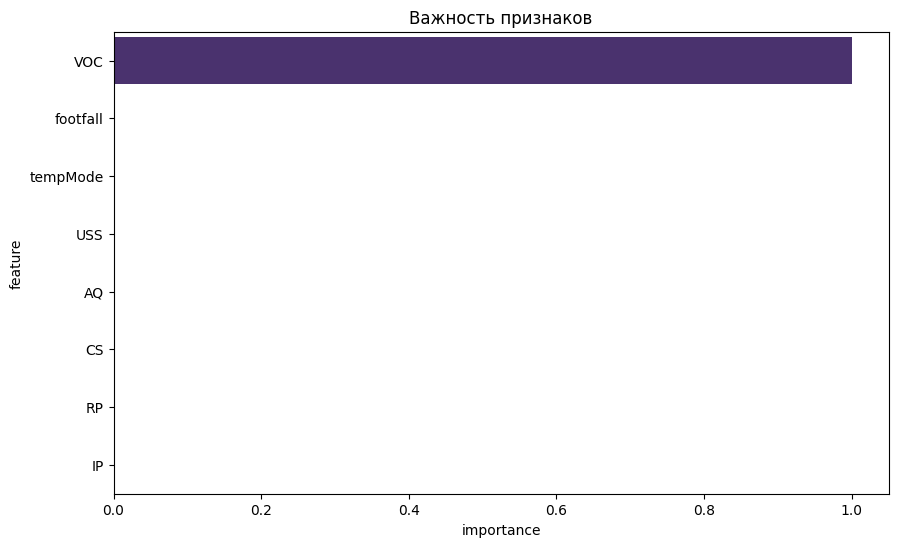

In [78]:
importances = grid.best_estimator_.feature_importances_
feat_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp.head(8), x='importance', y='feature', palette='viridis')
plt.title('Важность признаков')
plt.show()

**Собственная реализация**

In [79]:
class MyDecisionTreeClassifier:
    def __init__(self, max_depth=5):
        self.max_depth = max_depth
        self.tree = None

    def _gini(self, y):
        m = len(y)
        if m == 0: return 0
        return 1 - sum((np.sum(y == c) / m) ** 2 for c in np.unique(y))

    def _best_split(self, X, y):
        best_gini, best_feature, best_threshold = 1, None, None
        for feature in range(X.shape[1]):
            thresholds = np.unique(X[:, feature])
            for th in thresholds:
                left = X[:, feature] <= th
                right = ~left
                if np.sum(left) == 0 or np.sum(right) == 0: continue
                gini = (np.sum(left) * self._gini(y[left]) + np.sum(right) * self._gini(y[right])) / len(y)
                if gini < best_gini:
                    best_gini, best_feature, best_threshold = gini, feature, th
        return best_feature, best_threshold

    def _build_tree(self, X, y, depth=0):
        if depth >= self.max_depth or len(np.unique(y)) == 1:
            return {'class': Counter(y).most_common(1)[0][0]}
        feature, threshold = self._best_split(X, y)
        if feature is None: return {'class': Counter(y).most_common(1)[0][0]}
        left_mask = X[:, feature] <= threshold
        return {
            'feature': feature,
            'threshold': threshold,
            'left': self._build_tree(X[left_mask], y[left_mask], depth + 1),
            'right': self._build_tree(X[~left_mask], y[~left_mask], depth + 1)
        }

    def fit(self, X, y):
        self.tree = self._build_tree(np.array(X), np.array(y))

    def _predict_sample(self, x, tree):
        if 'class' in tree: return tree['class']
        if x[tree['feature']] <= tree['threshold']:
            return self._predict_sample(x, tree['left'])
        else:
            return self._predict_sample(x, tree['right'])

    def predict(self, X, threshold=0.5):
        proba = self.predict_proba(X)
        return (proba >= threshold).astype(int)

    def predict_proba(self, X):
        X = np.array(X)
        return np.array([self._predict_proba_sample(x, self.tree) for x in X])

    def _predict_proba_sample(self, x, tree):
        if 'class' in tree:
            return 1.0 if tree['class'] == 1 else 0.0
        if x[tree['feature']] <= tree['threshold']:
            return self._predict_proba_sample(x, tree['left'])
        else:
            return self._predict_proba_sample(x, tree['right'])

**Обучение слабой модели**

In [80]:
my_tree = MyDecisionTreeClassifier(max_depth=20)
my_tree.fit(X_train, y_train)
y_pred_custom_base = my_tree.predict(X_test)

acc_custom_base = accuracy_score(y_test, y_pred_custom_base)
f1_custom_base = f1_score(y_test, y_pred_custom_base)

print("\n🔧 Собственная реализация решающего дерева:")
print(f"Accuracy: {acc_custom_base:.4f} | F1: {f1_custom_base:.4f}")


🔧 Собственная реализация решающего дерева:
Accuracy: 0.8677 | F1: 0.8408


**Обучение сильной модели**

In [81]:
my_tree = MyDecisionTreeClassifier(max_depth=2)
my_tree.fit(X_train, y_train)
y_pred_custom = my_tree.predict(X_test)

acc_custom = accuracy_score(y_test, y_pred_custom)
f1_custom = f1_score(y_test, y_pred_custom)

print("\n🔧 Собственная реализация решающего дерева:")
print(f"Accuracy: {acc_custom:.4f} | F1: {f1_custom:.4f}")


🔧 Собственная реализация решающего дерева:
Accuracy: 0.9206 | F1: 0.9102


In [112]:
results = pd.DataFrame({
    'Модель': [
        'Бейзлайн',
        'Улучшенная модель',
        'Собственная реализация слабая модель',
        'Собственная реализация  сильная модель'
    ],
    'Accuracy': [acc_bl, acc_imp, acc_custom_base, acc_custom],
    'F1': [f1_bl, f1_imp, f1_custom_base, f1_custom]
})
results

,Модель,Accuracy,F1
0,Бейзлайн,0.867725,0.840764
1,Улучшенная модель,0.920635,0.910180
2,Собственная реализация слабая модель,0.867725,0.840764
3,Собственная реализация сильная модель,0.920635,0.910180


Регрессия
=

**Импорт необходимых библиотек**

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

**Загрузка датасета и фильтрация данных**

In [95]:
df = pd.read_csv('data.csv', header=None)

columns = [
    'price', 'building_type', 'district', 'floor', 'city',
    'rooms', 'total_area', 'living_area', 'kitchen_area', 'balcony',
    'floor_level', 'renovation'
]
df.columns = columns

numeric_cols = ['price', 'floor', 'rooms', 'total_area', 'living_area', 'kitchen_area', 'balcony', 'floor_level']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
df = df.dropna(subset=['price'])
df = df[df['price'] <= 120_000_000]
df = df[(df['total_area'] > 10) & (df['total_area'] <= 300)]
df = df[df['rooms'] > 0]

print(f"Объектов после фильтрации: {len(df)}")

Объектов после фильтрации: 17356


**Создание новых признаков и One-Hot encoding**

In [97]:
df['floor_ratio'] = df['floor'] / df['floor_level']
df['area_per_room'] = df['total_area'] / df['rooms']

df = pd.get_dummies(df, columns=['district', 'renovation'], drop_first=True)

df['log_price'] = np.log(df['price'])

print(f"Число признаков после One-Hot: {df.shape[1] - 2}")

Число признаков после One-Hot: 527


**Обучение бейзлайна**

In [99]:
numeric_features = ['total_area', 'living_area', 'kitchen_area', 'floor', 'area_per_room', 'floor_ratio']
X_all = df[numeric_features]
y_all = df['log_price']

X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.2, random_state=42)

tree_bl = DecisionTreeRegressor(random_state=42)
tree_bl.fit(X_train, y_train)
y_pred_bl = tree_bl.predict(X_test)

r2_bl = r2_score(y_test, y_pred_bl)
mae_bl = mean_absolute_error(np.exp(y_test), np.exp(y_pred_bl))

print(f"MAE: {mae_bl:,.0f} руб. | R²: {r2_bl:.4f}")

MAE: 4,933,233 руб. | R²: 0.7959


**Улучшение бейзлайна**

In [110]:
feature_cols = [col for col in df.columns if col not in ['price', 'log_price', 'building_type', 'city']]
X_imp = df[feature_cols]
y_imp = df['log_price']

X_train_imp, X_test_imp, y_train_imp, y_test_imp = train_test_split(X_imp, y_imp, test_size=0.2, random_state=42)

param_grid = {
    'max_depth': range(1, 31),
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf': [5, 10, 20],
    'max_features': ['sqrt', None]
}

grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
grid.fit(X_train_imp, y_train_imp)

y_pred_imp = grid.predict(X_test_imp)
r2_imp = r2_score(y_test_imp, y_pred_imp)
mae_imp = mean_absolute_error(np.exp(y_test_imp), np.exp(y_pred_imp))

print(f"MAE: {mae_imp:,.0f} руб. | R²: {r2_imp:.4f}")
print(f"Лучшие параметры: {grid.best_params_}")

MAE: 4,233,225 руб. | R²: 0.8968
Лучшие параметры: {'max_depth': 25, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 50}


**Визуализация дерева**

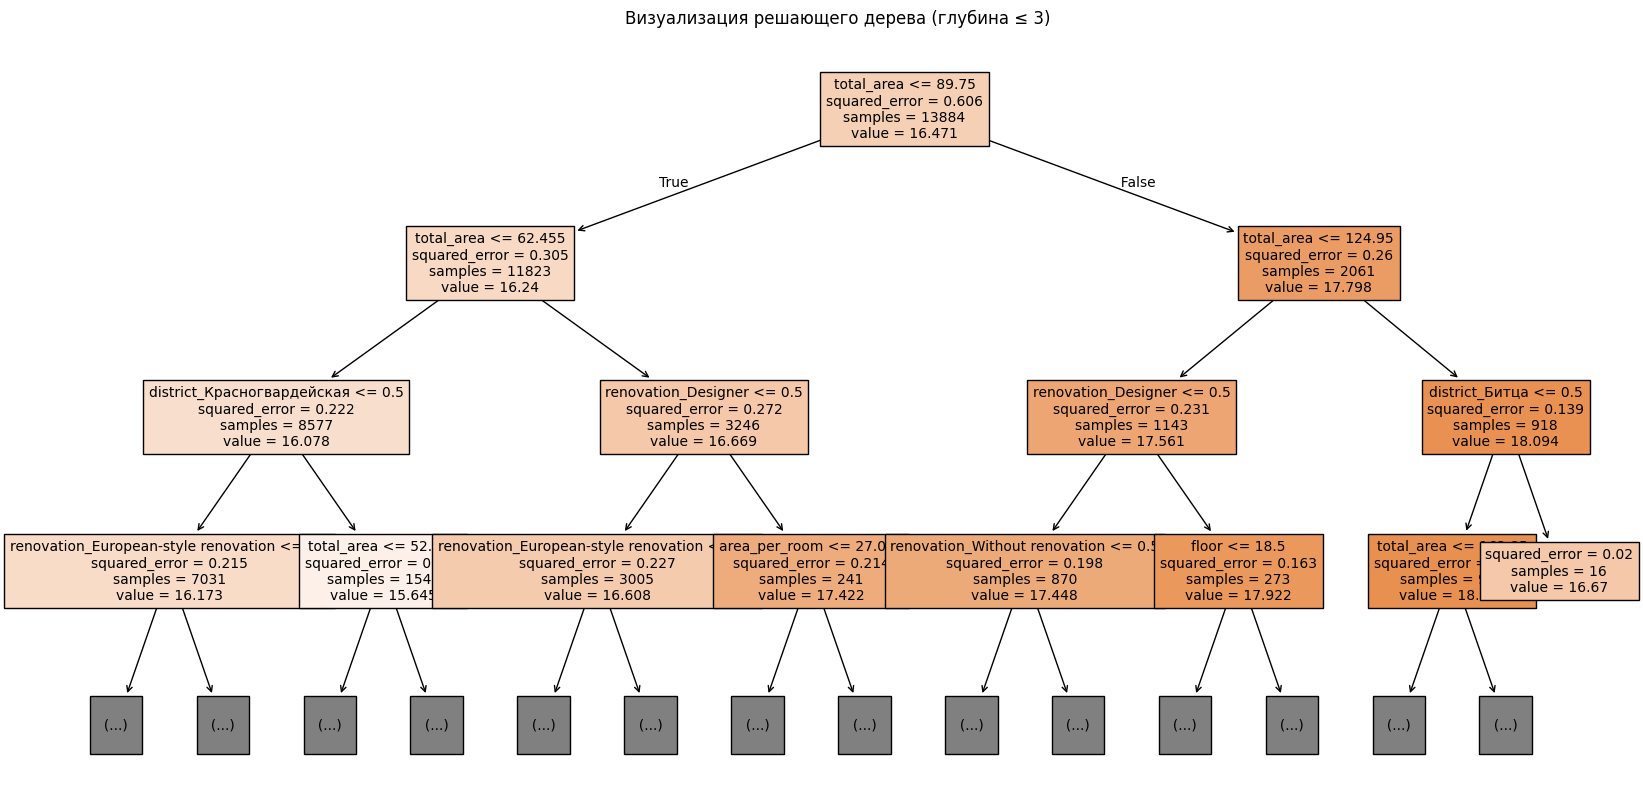

In [103]:
plt.figure(figsize=(20, 10))
plot_tree(
    grid.best_estimator_,
    max_depth=3,
    feature_names=feature_cols,
    filled=True,
    fontsize=10
)
plt.title('Визуализация решающего дерева (глубина ≤ 3)')
plt.show()

**Собственная реализация**

In [ ]:
class MyDecisionTreeRegressor:
    def __init__(self, max_depth=5):
        self.max_depth = max_depth
        self.tree = None

    def _mse(self, y):
        if len(y) == 0: return 0
        return np.var(y) * len(y)

    def _best_split(self, X, y):
        best_mse, best_feature, best_threshold = float('inf'), None, None
        for feature in range(X.shape[1]):
            thresholds = np.unique(X[:, feature])
            for th in thresholds:
                left = X[:, feature] <= th
                right = ~left
                if np.sum(left) == 0 or np.sum(right) == 0: continue
                mse = self._mse(y[left]) + self._mse(y[right])
                if mse < best_mse:
                    best_mse, best_feature, best_threshold = mse, feature, th
        return best_feature, best_threshold

    def _build_tree(self, X, y, depth=0):
        if depth >= self.max_depth or len(np.unique(y)) == 1:
            return {'value': np.mean(y)}
        feature, threshold = self._best_split(X, y)
        if feature is None: return {'value': np.mean(y)}
        left_mask = X[:, feature] <= threshold
        return {
            'feature': feature,
            'threshold': threshold,
            'left': self._build_tree(X[left_mask], y[left_mask], depth + 1),
            'right': self._build_tree(X[~left_mask], y[~left_mask], depth + 1)
        }

    def fit(self, X, y):
        X = np.array(X); y = np.array(y)
        self.tree = self._build_tree(X, y)

    def _predict_sample(self, x, tree):
        if 'value' in tree: return tree['value']
        if x[tree['feature']] <= tree['threshold']:
            return self._predict_sample(x, tree['left'])
        else:
            return self._predict_sample(x, tree['right'])

    def predict(self, X):
        X = np.array(X)
        return np.array([self._predict_sample(x, self.tree) for x in X])

**Обучение сырой модели**

In [105]:
my_tree = MyDecisionTreeRegressor(max_depth=10)
my_tree.fit(X_train, y_train)
y_pred_custom_base = my_tree.predict(X_test)

r2_custom_base = r2_score(y_test, y_pred_custom_base)
mae_custom_base = mean_absolute_error(np.exp(y_test), np.exp(y_pred_custom_base))

print(f"MAE: {mae_custom_base:,.0f} руб. | R²: {r2_custom_base:.4f}")

MAE: 5,781,875 руб. | R²: 0.7579


**Обучение сильной модели**

In [107]:
my_tree = MyDecisionTreeRegressor(max_depth=25)
my_tree.fit(X_train_imp, y_train_imp)
y_pred_custom = my_tree.predict(X_test_imp)

r2_custom = r2_score(y_test, y_pred_custom)
mae_custom = mean_absolute_error(np.exp(y_test), np.exp(y_pred_custom))

print(f"MAE: {mae_custom:,.0f} руб. | R²: {r2_custom:.4f}")

MAE: 4,008,928 руб. | R²: 0.8864


**Итоговая таблица**

In [111]:
results = pd.DataFrame({
    'Модель': ['Бейзлайн (числовые)', 'Улучшенная модель (One-Hot)', 'Собственная реализация грязные данные', 'Собственная реализация чистые данные'],
    'MAE (руб.)': [mae_bl, mae_imp, mae_custom_base, mae_custom],
    'R²': [r2_bl, r2_imp, r2_custom_base, r2_custom]
})
results

,Модель,MAE (руб.),R²
0,Бейзлайн (числовые),4.933233e+06,0.795913
1,Улучшенная модель (One-Hot),4.233225e+06,0.896769
2,Собственная реализация грязные данные,5.781875e+06,0.757918
3,Собственная реализация чистые данные,4.008928e+06,0.886427
